# Convolutional Neural Networks

## Look for the same clue in different places

Imagine sorting small camera images of labels carrying horizontal or vertical stripes. A stripe may appear anywhere in the frame. A fully connected network can learn this, but flattening an image gives it no built-in rule that neighboring pixels belong together or that the same clue can recur elsewhere.

A **convolutional neural network (CNN)** slides a small learned filter across a spatial grid. The same weights inspect every patch, producing a **feature map** of responses. Early layers can respond to local edges; later layers combine patterns over larger regions. Which patterns actually emerge depends on the data and training objective.

The [code companion](14_Convolutional_Neural_Networks.ipynb) works through the arithmetic and trains a CPU classifier on generated bar images.

## Start with the problem this lesson solves

Suppose a camera must distinguish horizontal and vertical bars, but the bar can appear at many positions. Flattening the image into an MLP is possible, yet it does not explicitly reuse the same small pattern detector across locations. A CNN is an ANN designed to share local filters across a grid.

A filter produces a response wherever a local pattern appears. Later layers combine these responses into a decision. Sharing weights reduces the number of learned values and makes evidence reusable across image positions; it does not automatically guarantee invariance to every shift or rotation.

## Connect pixels all the way to a loss and a filter update

Use the small image and hand-chosen filter from the arithmetic example:

$$X=\begin{bmatrix}0&1&0&0\\0&1&0&0\\0&1&0&0\\0&1&0&0\end{bmatrix},\qquad
K=\begin{bmatrix}1&-1\\1&-1\end{bmatrix}.$$

**Inspect every distinct patch.** With stride one and no padding, there are three horizontal positions and three vertical positions. All rows of this image are identical, so every output row has the same calculations:

- Left patch: $0(1)+1(-1)+0(1)+1(-1)=-2$.
- Middle patch: $1(1)+0(-1)+1(1)+0(-1)=2$.
- Right patch: $0(1)+0(-1)+0(1)+0(-1)=0$.

Thus the feature map is $[[-2,2,0],[-2,2,0],[-2,2,0]]$. The filter measures a left-minus-right contrast; the same four weights are reused nine times.

**Turn detected evidence into a score.** ReLU gives $[[0,2,0],[0,2,0],[0,2,0]]$. In this teaching-only classifier, average all nine values: $s=(0+2+0+0+2+0+0+2+0)/9=2/3$. Use fixed class logits $[0,s]$, with class zero meaning horizontal and class one meaning vertical, matching the companion's labels.

Softmax gives $p_{vertical}=e^{2/3}/(e^{2/3}+1)\approx0.660756$. For this vertical image, cross-entropy is $-\ln(0.660756)\approx0.414370$. The loss says the correct class should receive more probability.

**Carry that request back to the shared filter.** The derivative with respect to $s$ is $p_{vertical}-1\approx-0.339244$. Averaging gives each feature-map entry a factor $1/9$. ReLU passes gradients only through the three positive entries here. Each active patch is $[[1,0],[1,0]]$, so the gradient of each left-column filter weight is

$$(-0.339244)\times\frac{1}{9}\times(1+1+1)\approx-0.113081.$$

The right-column weights multiply zeros in these active patches, so their gradients are zero. At SGD rate $0.1$, the updated filter is approximately $[[1.011308,-1],[1.011308,-1]]$. Its positive responses become $2.022616$, the mean becomes about $0.674205$, and the vertical probability increases. One shared update strengthened the detector at all three active positions.

This is one filter, one image, no convolution bias, and a fixed output head so the whole learning calculation fits on the page. It is not the trained two-block CNN below. Training on many horizontal and vertical examples is needed to establish a useful orientation classifier.

## Why the ANN's structure matches this problem

Convolution looks for local patterns, ReLU allows nonlinear combinations, pooling summarizes responses, and the final layer turns learned features into class scores. Backpropagation collects contributions from every position where a shared filter was used. The optimizer then changes the filter once using their combined evidence.

This can help a detector work at several locations without storing an unrelated weight for each location. It can also lose information: pooling discards spatial detail, and padding or stride affects responses near boundaries and after shifts. The companion evaluates independently generated bar images; success on them does not establish performance on real photographs or new image conditions.

## Keep the image grid intact

An image is an array of pixel measurements. A grayscale image has one channel; an RGB image has three. PyTorch convolution uses `(N, C, H, W)`: batch size, channels, height, width. Four RGB images of size 16 × 16 therefore have shape `(4, 3, 16, 16)`. Other tools may place channels last, so check the layout rather than guessing.

A filter spans all input channels and a small spatial window. Eight filters produce eight output channels. Channels are learned measurements, not eight separate input images. Pixel scaling should be consistent across splits; any estimated means and standard deviations must come from training data.

## Work through one shared filter

Take the image and filter

$$X=\begin{bmatrix}0&1&0&0\\0&1&0&0\\0&1&0&0\\0&1&0&0\end{bmatrix},\qquad K=\begin{bmatrix}1&-1\\1&-1\end{bmatrix}.$$

At the upper-left patch, multiply corresponding entries and add:

$$0(1)+1(-1)+0(1)+1(-1)=-2.$$

Move one pixel right: $1(1)+0(-1)+1(1)+0(-1)=2$. The next patch gives zero. With stride one, no padding, and zero bias, the complete output is

$$Y=\begin{bmatrix}-2&2&0\\-2&2&0\\-2&2&0\end{bmatrix}.$$

The sign distinguishes the two sides of the stripe. ReLU turns negative values into zero, so different filters may be needed to retain both edge directions. Deep-learning libraries typically compute **cross-correlation**, without flipping the kernel; this operation is conventionally called convolution in CNNs.

## Control size with padding and stride

**Stride** is the distance between neighboring filter positions. **Padding** adds a border, often zeros, so filters can reach boundary pixels and output size can be controlled. **Dilation** spaces out the filter samples. For one spatial dimension,

$$H_{out}=\left\lfloor\frac{H+2P-D(K-1)-1}{S}\right\rfloor+1.$$

Here $H$ is input height, $P$ padding per side, $K$ kernel size, $D$ dilation, and $S$ stride. Apply the same formula to width. For $H=16,K=3,P=1,S=D=1$, output height is 16. A 2 × 2 max pool with stride two then reduces it to eight. For the 4 × 4 arithmetic image, a 2 × 2 filter with padding one and stride two gives a 3 × 3 result.

Padding introduces artificial boundary values. Increasing stride reduces computation and spatial detail; it can also make small shifts change the result.

## Count what is learned

For a standard convolution with bias,

$$\text{parameters}=C_{out}(C_{in}K_hK_w+1).$$

For three input channels, eight output channels, and 3 × 3 filters, this is $8(3\times3\times3+1)=224$. There is one bias per output channel. Each output value sums products across all input channels and spatial positions in its patch, then adds that bias.

The count does not grow with image height or width, although computation and activation memory do. For comparison, flattening a 3 × 16 × 16 image into a dense layer with 128 outputs requires $768\times128+128=98,432$ parameters. These layers produce different representations; the calculation illustrates weight sharing rather than equivalent model quality.

## Combine responses and widen the view

A common block applies convolution → ReLU → pooling. ReLU supplies nonlinearity. Max pooling returns the largest value in each window: `[[1, 3], [2, 0]]` becomes `3`. Average pooling returns the mean, here `1.5`. Pooling has no learned weights.

A neuron's **receptive field** is the input region that can affect it. Two stride-one 3 × 3 convolutions without intervening pooling give an interior output a 5 × 5 receptive field. In the companion, convolution → 2 × 2 pooling → convolution gives an interior final feature a theoretical 8 × 8 receptive field. Global average pooling then summarizes all spatial positions in each channel.

Weight sharing encourages translation equivariance: shifting an input tends to shift its feature map away from boundaries. Strides, finite borders, and pooling complicate this relationship. A classifier is not automatically invariant to every translation, rotation, or scale change.

## Follow one image through the classifier

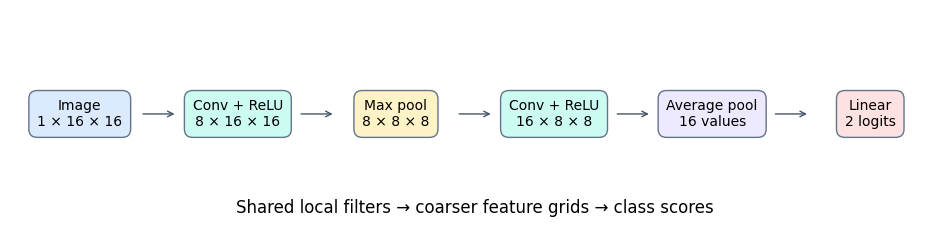

The batch dimension is omitted. The model learns 1,282 parameters: 80 in the first convolution, 1,168 in the second, and 34 in the final linear layer. Global pooling preserves channel identity while removing explicit spatial coordinates.

## Learn filters from classification mistakes

The illustrative edge filter was chosen by hand. The classifier instead starts with random weights. For each minibatch it computes two logits per image, evaluates cross-entropy against the true class, backpropagates through the whole network, and updates the filters and final layer with Adam.

Because a filter weight is reused across the image, its gradient accumulates contributions from all positions where it was used. Training therefore teaches a shared detector rather than a separate weight for each image location. Cross-entropy expects raw logits; softmax is useful afterward if class probabilities are needed.

The companion generates 600 training, 160 validation, and 200 test images using separate random seeds. Over 35 epochs, validation loss selects a saved checkpoint. Test images are evaluated only after restoring that checkpoint. Balanced labels give the training-majority baseline 50% test accuracy.

## Decide where convolution helps

CNNs are useful when nearby measurements form reusable patterns: image recognition, document imagery, audio spectrograms, and spatial sensor grids. Classification predicts a label for an image; detection also locates objects, while segmentation predicts labels across pixels. These latter tasks need output structures that preserve or recover location.

Convolution assumes local structure and shared pattern usefulness. It is less natural for an arbitrary table whose adjacent columns have unrelated meanings. Small datasets can still cause overfitting, and a CNN can exploit shortcuts such as backgrounds instead of the intended object. Pooling may erase fine detail, and local filters may need many layers or other mechanisms to capture distant relationships.

The bar experiment tests new samples from a simple known process. Strong accuracy does not establish robustness to real photographs, new bar lengths, rotations, or changed noise. Compare stronger baselines and evaluate realistic shifts before drawing broader conclusions.

## See the sliding-filter calculation

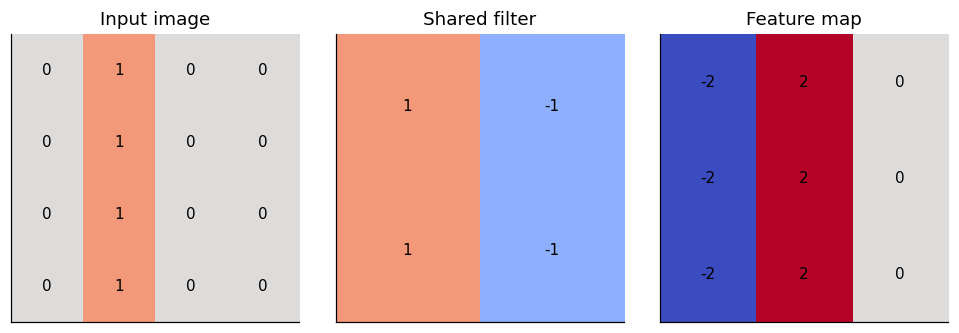

The same filter yields negative, positive, and zero responses at different locations.

## Inspect the generated images

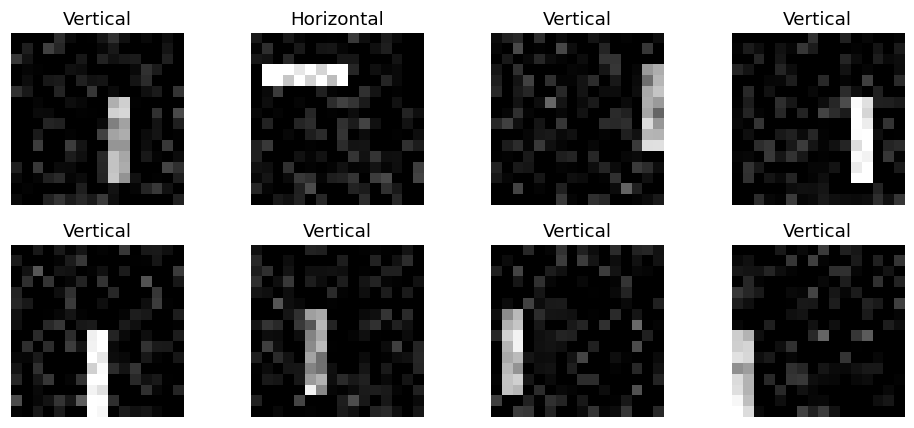

Bars vary in position and brightness; orientation determines the label.

## Read the held-out confusion matrix

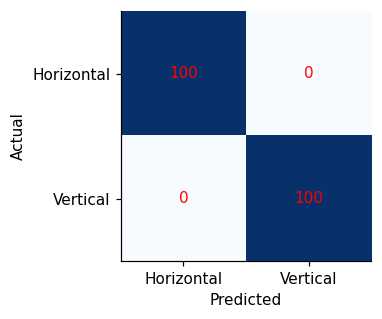

Rows are true labels and columns are predictions on new samples from the bar generator.